r=1, error for each N: [0.01552566489919421, 0.018754358289855118, 0.021550391366814137, 0.023982499639666897, 0.0262237217908248, 0.028258038392699584, 0.030182674782015625]
r=2, error for each N: [0.0038329802270404517, 0.004629793422931033, 0.005318173169957412, 0.0059186907477814, 0.006470698868107172, 0.0069732076551600524, 0.007447452943714306]
r=3, error for each N: [0.0016999568134687044, 0.0020533588946751707, 0.002358472800104409, 0.0026248559467691055, 0.0028695567313144327, 0.0030925369145541034, 0.00330286474233712]
r=7, error for each N: [0.00031235976416279707, 0.0003773057510650276, 0.00043332242397794724, 0.00048230858384600906, 0.0005272663690262237, 0.0005683638518983474, 0.0006071549110813201]


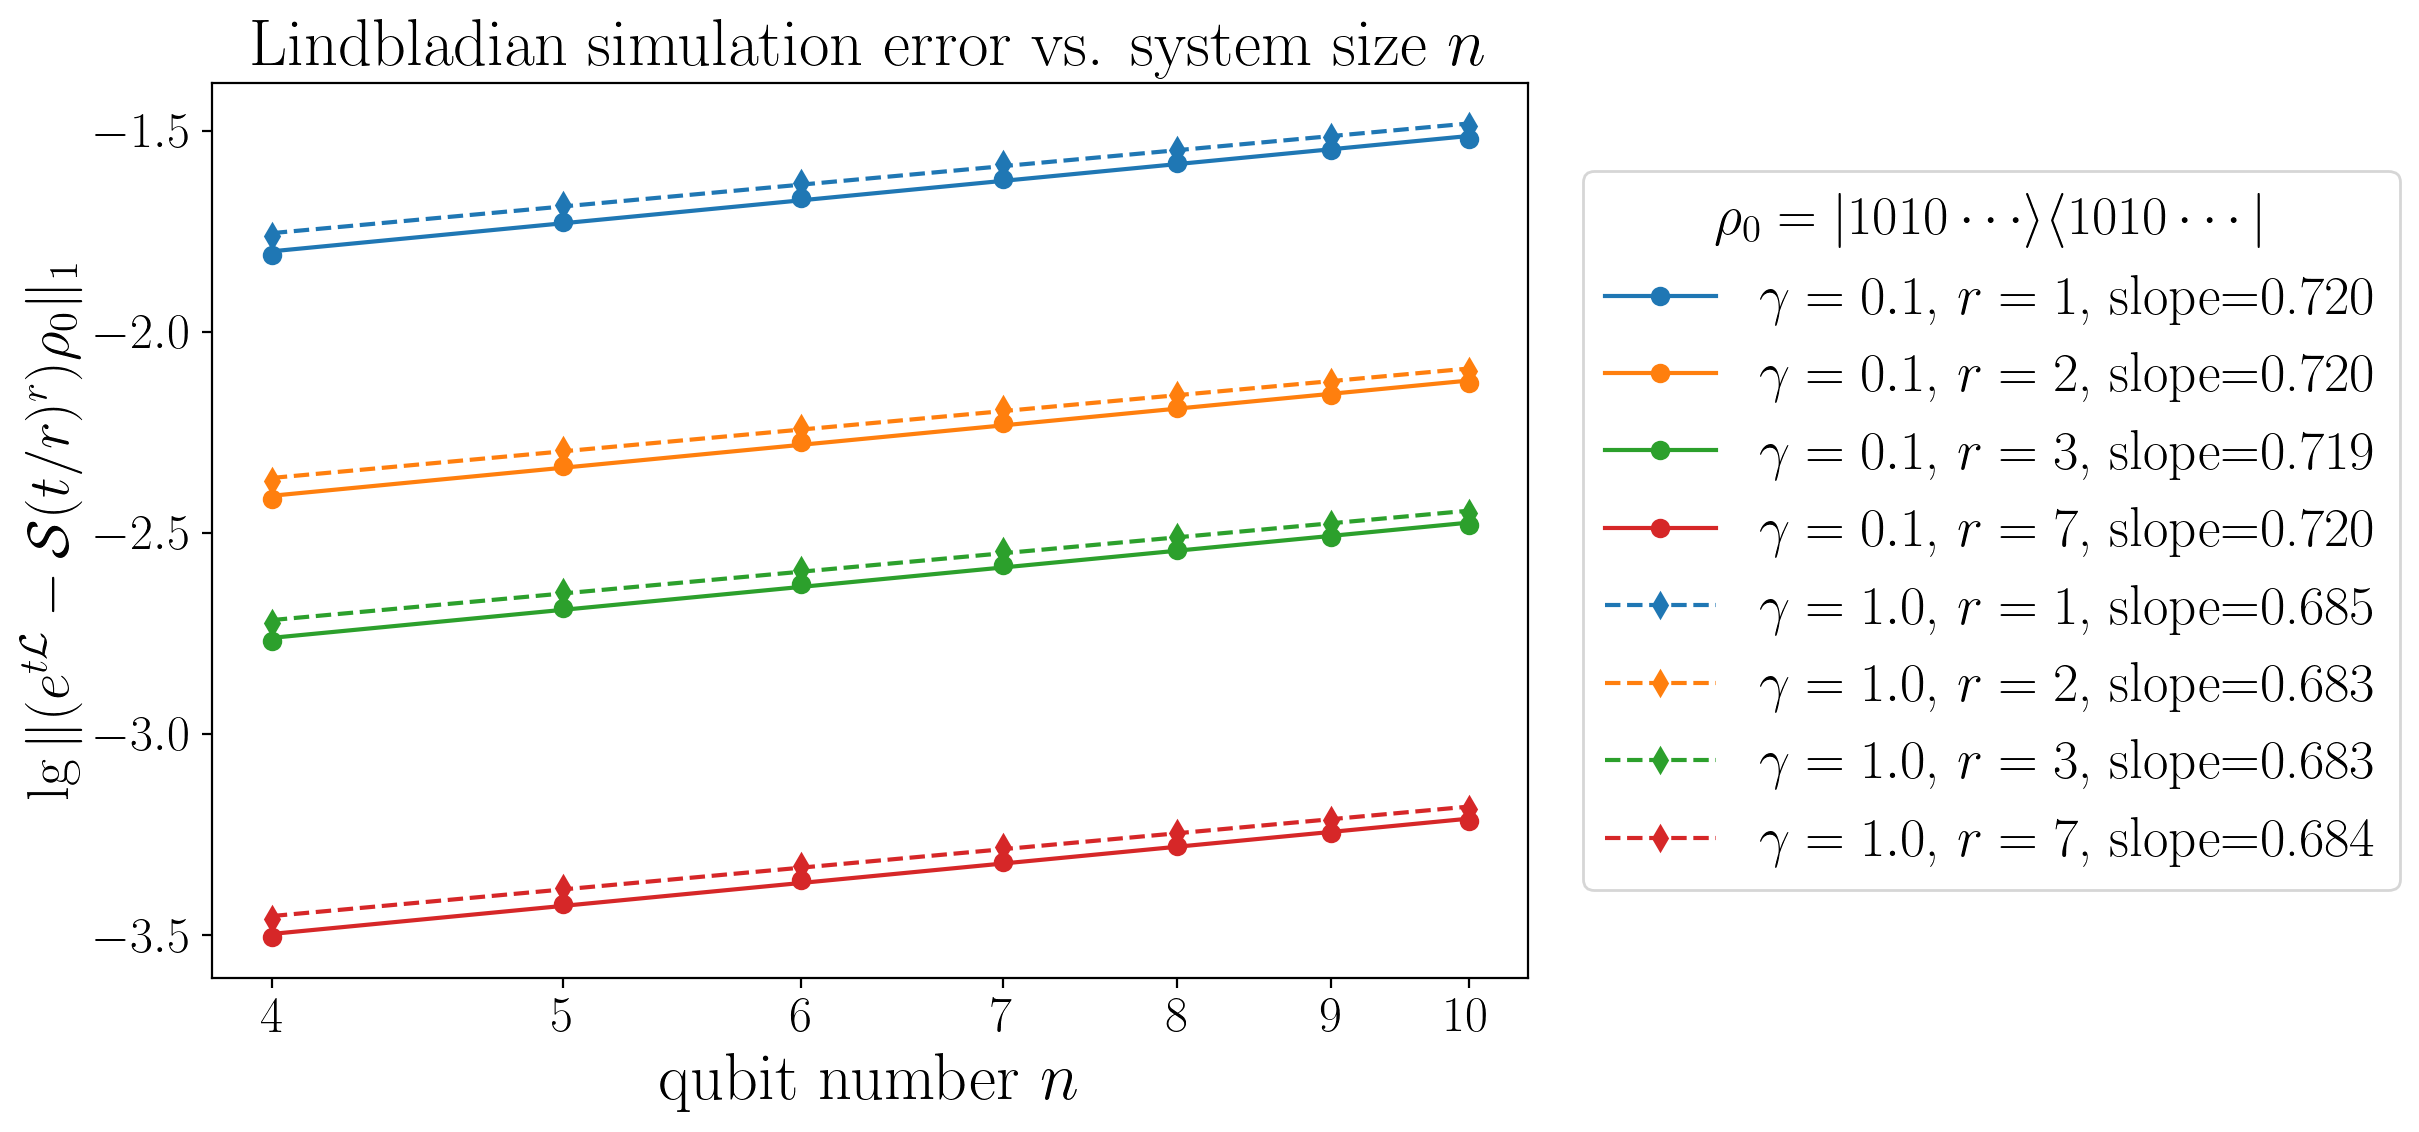

In [3]:
'''
This script is for the general folder other than "./data_sigmap/|000>initial/"
initial can be changed to "|111>" or "|+++>" etc.
'''
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D
import qutip as qt

# 设置全局字体为 Times New Roman
%config InlineBackend.figure_format = 'retina'
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams.update({"font.size": 18})

# 启用 LaTeX 渲染
plt.rcParams["text.usetex"] = True

#  N = 2 偏离直线太多了
initial_list = ["000", "111", "101", "+++", "mixed"]
initial = initial_list[2]  # change here for different initial states
legend_title_dict = {
    "000": r'$\rho_0 = |0^n\rangle \langle 0^n|$',
    "111": r'$\rho_0 = |1^n\rangle \langle 1^n|$',
    "+++": r'$\rho_0 = |+^n\rangle \langle +^n|$',
    "101": r'$\rho_0 = |1010\cdots\rangle \langle 1010\cdots|$',
    "mixed": r'$\rho_0 = I^{\otimes n}/{2^n}$'
}
legend_title = legend_title_dict[initial]

N_list = np.arange(4,11)
r_list = np.array([1, 2, 3, 7])

# trace norm of the difference between output density matrix
color = 0
handles = []
fig, ax = plt.subplots(figsize=(12.5, 6))

# e{tL} Euler step:
step = 100000
# display(Latex(r'$\gamma=0.1$'))
'''
For N = 4 to 10, the exp(H_x) is exact, 
whereas the jump operator are first-order approximated by 1000 steps.
'''
for r in r_list:
    gamma = 0.1
    error_1_list = []
    for N in N_list:
        if initial == '000':
            rho_exact = np.load(f"../data/|{initial}>initial/gamma_{gamma}/exp(tL)_Euler/rho_exact_N_{N}_step_{step}.npy")
            if N >=11:
                rho_Trotter = np.load(f"../data/|{initial}>initial/gamma_{gamma}/Trotter_Euler_exp(H)_1000/rho_N_{N}_r_{r}.npy")
            else:
                rho_Trotter = np.load(f"../data/|{initial}>initial/gamma_{gamma}/Trotter_Euler_1000/rho_N_{N}_r_{r}.npy")
            if N <=5:
                rho_superexact = np.load(f"../data/|{initial}>initial/gamma_{gamma}/superexact/rho_superexact_N_{N}.npy")
        else: 
            rho_Trotter = np.load(f"../data/|{initial}>initial/gamma_{gamma}/rho_N_{N}_r_{r}.npy")
            rho_exact = np.load(f"../data/|{initial}>initial/gamma_{gamma}/rho_exact_N_{N}_step_{step}.npy")
            
        error_1_list.append(qt.Qobj(rho_Trotter - rho_exact).norm("tr")) 
        
    # gamma = 0.1
    print(f'r={r}, error for each N:', error_1_list) 

    logN = np.log(N_list)/np.log(10)
    logE1 = np.log(error_1_list)/np.log(10)
    k, b = np.polyfit(logN, logE1, 1)

    x = np.linspace(logN.min(), logN.max(), 100)
    ax.plot(logN, logE1, "o", color=f"C{color}")
    ax.plot(x, k * x + b, color=f"C{color}")

    legend_handle = Line2D(
        [0], [0],
        color=f"C{color}",
        linestyle="-",
        marker="o",
        markersize=6,
        label=f"$\\gamma=0.1$, $r={r}$, slope={k:.3f}",
    )
    handles.append(legend_handle)
    color += 1

color = 0
for r in r_list:
    gamma = 1.0
    error_2_list = []
    for N in N_list:
        if initial == '000':
            rho_exact = np.load(f"../data/|{initial}>initial/gamma_{gamma}/exp(tL)_Euler/rho_exact_N_{N}_step_{step}.npy")
            if N >=11:
                rho_Trotter = np.load(f"../data/|{initial}>initial/gamma_{gamma}/Trotter_Euler_exp(H)_1000/rho_N_{N}_r_{r}.npy")
            else:
                rho_Trotter = np.load(f"../data/|{initial}>initial/gamma_{gamma}/Trotter_Euler_1000/rho_N_{N}_r_{r}.npy")
            if N <=5:
                rho_superexact = np.load(f"../data/|{initial}>initial/gamma_{gamma}/superexact/rho_superexact_N_{N}.npy")
        else: 
            rho_Trotter = np.load(f"../data/|{initial}>initial/gamma_{gamma}/rho_N_{N}_r_{r}.npy")
            rho_exact = np.load(f"../data/|{initial}>initial/gamma_{gamma}/rho_exact_N_{N}_step_{step}.npy")
            
        error_2_list.append(qt.Qobj(rho_Trotter - rho_exact).norm("tr"))
        
    logE2 = np.log(error_2_list)/np.log(10)
    k, b = np.polyfit(logN, logE2, 1)

    x = np.linspace(logN.min(), logN.max(), 100)
    ax.plot(logN, logE2, "d", color=f"C{color}")
    ax.plot(x, k * x + b, linestyle="--", color=f"C{color}")

    legend_handle = Line2D(
        [0], [0],
        color=f"C{color}",
        linestyle="--",
        marker="d",
        markersize=6,
        label=f"$\\gamma=1.0$, $r={r}$, slope={k:.3f}",
    )
    handles.append(legend_handle)
    color += 1

ax.legend(title=legend_title, title_fontsize=20, handles=handles, loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=20)

# ax.set_xscale("log")

ax.set_xticks(logN)
ax.set_xticklabels([str(n) for n in N_list])
# ax.tick_params(axis="x", labelsize=10)
if not initial == "mixed":
    ax.set_yticks([-3.5, -3, -2.5, -2, -1.5])
    
ax.set_xlabel("qubit number $n$", fontsize = 24)
ax.set_ylabel("$\lg \|(e^{t\mathcal{L}}-\mathcal{S}(t/r)^r)\\rho_0\|_1$", fontsize = 21)
ax.set_title(f"Lindbladian simulation error vs. system size $n$", fontsize = 24)
# ax.set(x_label='x', y_label='y', title = 't')

# ax.set_xscale('log')
fig.tight_layout() # 不加 pdf 会不完整，错误剪裁

plt.savefig(f'error-N-{initial}.pdf')
    
plt.show()